In [1]:
import multiprocessing
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from parameter_sweeps import run_default_600_day_selectivity
from src.model import SSCNetwork
from src.model_outgoing_ff import SSCNetwork as SSCNetworkOutgoingFF
from src.network_parameters import network_parameters
from src.utils.general import get_signal_to_noise_ratio



from src.utils.plotting import gray, gray_purple, purple


In [2]:
import os
import torch

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_DYNAMIC"] = "FALSE"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
try:
    multiprocessing.set_start_method("fork")
except RuntimeError:
    pass

In [8]:
num_swaps_values = [2, 6, 10, 14]
day_length_values = [5, 10, 15, 20, 30, 40, 60, 80, 100]
# Shared execution parameters for all sweeps below.
num_seeds = 12
seeds = list(range(num_seeds))
num_cpu = 12

measure_names = [
    "ctx_simple_mean_selectivity",
    "ctx_complex_mean_selectivity",
    "mtl_semantic_simple_mean_selectivity",
]


In [9]:
def run_selectivity_sweep_point(seed, num_swaps, day_length):
    summary = run_default_600_day_selectivity(
        seed=seed,
        print_rate=np.inf,
        input_parameter_overrides={
            "num_swaps": num_swaps,
            "day_length": day_length,
        },
    )
    return {
        "seed": int(seed),
        "num_swaps": int(num_swaps),
        "day_length": int(day_length),
        "ctx_simple_mean_selectivity": summary["ctx_simple_mean_selectivity"],
        "ctx_complex_mean_selectivity": summary["ctx_complex_mean_selectivity"],
        "mtl_semantic_simple_mean_selectivity": summary["mtl_semantic_simple_mean_selectivity"],
    }


In [10]:
experiment_params = [
    (seed, num_swaps, day_length)
    for num_swaps in num_swaps_values
    for day_length in day_length_values
    for seed in seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=num_cpu) as pool:
    sweep_results = pool.starmap(run_selectivity_sweep_point, experiment_params)

selectivity_seed_matrix = np.full(
    (len(num_swaps_values), len(day_length_values), num_seeds, len(measure_names)),
    np.nan,
)

for result in sweep_results:
    i = num_swaps_values.index(result["num_swaps"])
    j = day_length_values.index(result["day_length"])
    k = seeds.index(result["seed"])
    selectivity_seed_matrix[i, j, k, 0] = result["ctx_simple_mean_selectivity"]
    selectivity_seed_matrix[i, j, k, 1] = result["ctx_complex_mean_selectivity"]
    selectivity_seed_matrix[i, j, k, 2] = result["mtl_semantic_simple_mean_selectivity"]

selectivity_matrix = np.nanmean(selectivity_seed_matrix, axis=2)
selectivity_matrix_std = np.nanstd(selectivity_seed_matrix, axis=2)

print("selectivity_matrix shape (mean over seeds):", selectivity_matrix.shape)
print("selectivity_matrix_std shape:", selectivity_matrix_std.shape)
print("measure_names:", measure_names)

KeyboardInterrupt: 

In [6]:
ctx_simple_selectivity = selectivity_matrix[..., 0]
ctx_complex_selectivity = selectivity_matrix[..., 1]
mtl_semantic_simple_selectivity = selectivity_matrix[..., 2]

reference_recording_params = {
    "regions": [],
    "rate_activity": np.inf,
    "connections": [],
    "rate_connectivity": np.inf,
}
reference_network = SSCNetwork(network_parameters, reference_recording_params)
snr_values = np.asarray(
    [
        get_signal_to_noise_ratio(num_swaps, reference_network, region="mtl_sensory")
        for num_swaps in num_swaps_values
    ],
    dtype=float,
)

print("ctx_simple_selectivity shape:", ctx_simple_selectivity.shape)
print("ctx_complex_selectivity shape:", ctx_complex_selectivity.shape)
print("mtl_semantic_simple_selectivity shape:", mtl_semantic_simple_selectivity.shape)


ctx_simple_selectivity shape: (4, 9)
ctx_complex_selectivity shape: (4, 9)
mtl_semantic_simple_selectivity shape: (4, 9)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


In [16]:
snr_values = np.asarray(
    [
        get_signal_to_noise_ratio(num_swaps, reference_network, region="mtl_sensory")
        for num_swaps in num_swaps_values
    ],
    dtype=float,
)


NameError: name 'reference_network' is not defined

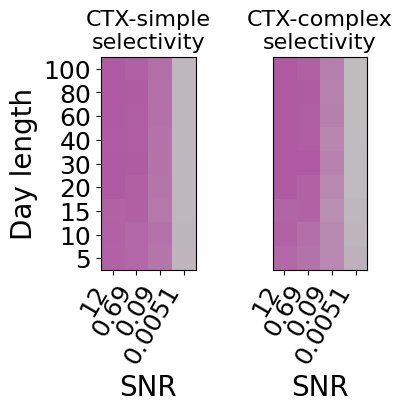

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(4, 4), constrained_layout=True, sharey=True)

plot_matrices = [
    (ctx_simple_selectivity.T, "CTX-simple\nselectivity"),
    (ctx_complex_selectivity.T, "CTX-complex\nselectivity"),
]


for ax, (matrix, title) in zip(axes, plot_matrices):
    im = ax.imshow(
        matrix,
        origin="lower",
        cmap=gray_purple,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("SNR", fontsize=20)
    ax.set_ylabel("Day length", fontsize=20)
    ax.set_xticks(np.arange(len(snr_values)))
    ax.set_xticklabels([f"{value:.2g}" for value in snr_values], rotation=60, ha="right")
    ax.set_yticks(np.arange(len(day_length_values)))
    ax.set_yticklabels(day_length_values)
    ax.tick_params(axis="both", labelsize=18)
axes[1].yaxis.set_visible(False)


plt.savefig("Figures/SVG/S9a.svg", dpi=300, transparent=True)

In [8]:
num_swaps_values = [2, 6, 10, 14]
episode_duration_values = [1, 2, 3, 4, 5, 10]

measure_names = [
    "ctx_simple_mean_selectivity",
    "ctx_complex_mean_selectivity",
    "mtl_semantic_simple_mean_selectivity",
]



In [9]:
def run_selectivity_sweep_point(seed, num_swaps, mean_duration):
    summary = run_default_600_day_selectivity(
        seed=seed,
        print_rate=np.inf,
        input_parameter_overrides={
            "num_swaps": num_swaps,
            "mean_duration": mean_duration,
        },
    )
    return {
        "seed": int(seed),
        "num_swaps": int(num_swaps),
        "mean_duration": int(mean_duration),
        "ctx_simple_mean_selectivity": summary["ctx_simple_mean_selectivity"],
        "ctx_complex_mean_selectivity": summary["ctx_complex_mean_selectivity"],
        "mtl_semantic_simple_mean_selectivity": summary["mtl_semantic_simple_mean_selectivity"],
    }


In [10]:
experiment_params = [
    (seed, num_swaps, mean_duration)
    for num_swaps in num_swaps_values
    for mean_duration in episode_duration_values
    for seed in seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=num_cpu) as pool:
    sweep_results = pool.starmap(run_selectivity_sweep_point, experiment_params)

selectivity_seed_matrix = np.full(
    (len(num_swaps_values), len(episode_duration_values), num_seeds, len(measure_names)),
    np.nan,
)

for result in sweep_results:
    i = num_swaps_values.index(result["num_swaps"])
    j = episode_duration_values.index(result["mean_duration"])
    k = seeds.index(result["seed"])
    selectivity_seed_matrix[i, j, k, 0] = result["ctx_simple_mean_selectivity"]
    selectivity_seed_matrix[i, j, k, 1] = result["ctx_complex_mean_selectivity"]
    selectivity_seed_matrix[i, j, k, 2] = result["mtl_semantic_simple_mean_selectivity"]

selectivity_matrix = np.nanmean(selectivity_seed_matrix, axis=2)
selectivity_matrix_std = np.nanstd(selectivity_seed_matrix, axis=2)

print("selectivity_matrix shape (mean over seeds):", selectivity_matrix.shape)
print("selectivity_matrix_std shape:", selectivity_matrix_std.shape)
print("measure_names:", measure_names)

selectivity_matrix shape (mean over seeds): (4, 6, 3)
selectivity_matrix_std shape: (4, 6, 3)
measure_names: ['ctx_simple_mean_selectivity', 'ctx_complex_mean_selectivity', 'mtl_semantic_simple_mean_selectivity']


In [11]:
ctx_simple_selectivity = selectivity_matrix[..., 0]
ctx_complex_selectivity = selectivity_matrix[..., 1]
mtl_semantic_simple_selectivity = selectivity_matrix[..., 2]

reference_recording_params = {
    "regions": [],
    "rate_activity": np.inf,
    "connections": [],
    "rate_connectivity": np.inf,
}
reference_network = SSCNetwork(network_parameters, reference_recording_params)
snr_values = np.asarray(
    [
        get_signal_to_noise_ratio(num_swaps, reference_network, region="mtl_sensory")
        for num_swaps in num_swaps_values
    ],
    dtype=float,
)

print("ctx_simple_selectivity shape:", ctx_simple_selectivity.shape)
print("ctx_complex_selectivity shape:", ctx_complex_selectivity.shape)
print("mtl_semantic_simple_selectivity shape:", mtl_semantic_simple_selectivity.shape)


ctx_simple_selectivity shape: (4, 6)
ctx_complex_selectivity shape: (4, 6)
mtl_semantic_simple_selectivity shape: (4, 6)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


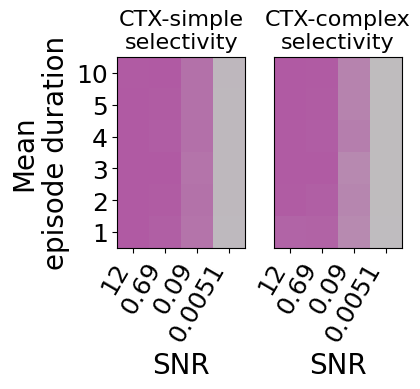

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(4, 4), constrained_layout=True, sharey=True)

plot_matrices = [
    (ctx_simple_selectivity.T, "CTX-simple\nselectivity"),
    (ctx_complex_selectivity.T, "CTX-complex\nselectivity"),
]
vmin = min(matrix.min() for matrix, _ in plot_matrices)
vmax = max(matrix.max() for matrix, _ in plot_matrices)

for ax, (matrix, title) in zip(axes, plot_matrices):
    im = ax.imshow(
        matrix,
        origin="lower",
        cmap=gray_purple,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("SNR", fontsize=20)
    ax.set_ylabel("Mean\nepisode duration", fontsize=20)
    ax.set_xticks(np.arange(len(snr_values)))
    ax.set_xticklabels([f"{value:.2g}" for value in snr_values], rotation=60, ha="right")
    ax.set_yticks(np.arange(len(episode_duration_values)))
    ax.set_yticklabels(episode_duration_values)
    ax.tick_params(axis="both", labelsize=18)
axes[1].yaxis.set_visible(False)

plt.savefig("Figures/SVG/S9b.svg", dpi=300, transparent=True)

In [13]:
num_swaps_values = [2, 6, 10, 14]
pattern_complete_iteration_values = [1, 2, 3, 4, 5, 10]

measure_names = [
    "ctx_simple_mean_selectivity",
    "ctx_complex_mean_selectivity",
    "mtl_semantic_simple_mean_selectivity",
]


In [14]:
def run_pattern_complete_iteration_sweep_point(seed, num_swaps, num_iterations):
    network_parameter_overrides = {
        "mtl_pattern_complete_iterations": num_iterations,
        "mtl_sensory_pattern_complete_iterations": num_iterations,
        "mtl_semantic_pattern_complete_iterations": num_iterations,
        "ctx_pattern_complete_iterations": num_iterations,
        "mtl_generate_pattern_complete_iterations": num_iterations,
    }
    summary = run_default_600_day_selectivity(
        seed=seed,
        print_rate=np.inf,
        network_parameter_overrides=network_parameter_overrides,
        input_parameter_overrides={"num_swaps": num_swaps},
    )
    return {
        "seed": int(seed),
        "num_swaps": int(num_swaps),
        "num_iterations": int(num_iterations),
        "ctx_simple_mean_selectivity": summary["ctx_simple_mean_selectivity"],
        "ctx_complex_mean_selectivity": summary["ctx_complex_mean_selectivity"],
        "mtl_semantic_simple_mean_selectivity": summary["mtl_semantic_simple_mean_selectivity"],
    }


In [15]:
pattern_complete_iteration_jobs = [
    (seed, num_swaps, num_iterations)
    for num_swaps in num_swaps_values
    for num_iterations in pattern_complete_iteration_values
    for seed in seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=min(num_cpu, len(pattern_complete_iteration_jobs))) as pool:
    pattern_complete_iteration_results = pool.starmap(
        run_pattern_complete_iteration_sweep_point,
        pattern_complete_iteration_jobs,
    )

pattern_complete_iteration_selectivity_seed_matrix = np.full(
    (len(num_swaps_values), len(pattern_complete_iteration_values), num_seeds, len(measure_names)),
    np.nan,
)

for result in pattern_complete_iteration_results:
    i = num_swaps_values.index(result["num_swaps"])
    j = pattern_complete_iteration_values.index(result["num_iterations"])
    k = seeds.index(result["seed"])
    pattern_complete_iteration_selectivity_seed_matrix[i, j, k, 0] = result["ctx_simple_mean_selectivity"]
    pattern_complete_iteration_selectivity_seed_matrix[i, j, k, 1] = result["ctx_complex_mean_selectivity"]
    pattern_complete_iteration_selectivity_seed_matrix[i, j, k, 2] = result["mtl_semantic_simple_mean_selectivity"]

pattern_complete_iteration_selectivity_matrix = np.nanmean(
    pattern_complete_iteration_selectivity_seed_matrix, axis=2
)
pattern_complete_iteration_selectivity_matrix_std = np.nanstd(
    pattern_complete_iteration_selectivity_seed_matrix, axis=2
)

print("pattern_complete_iteration_selectivity_matrix shape (mean over seeds):", pattern_complete_iteration_selectivity_matrix.shape)
print("pattern_complete_iteration_selectivity_matrix_std shape:", pattern_complete_iteration_selectivity_matrix_std.shape)
print("measure_names:", measure_names)


pattern_complete_iteration_selectivity_matrix shape (mean over seeds): (4, 6, 3)
pattern_complete_iteration_selectivity_matrix_std shape: (4, 6, 3)
measure_names: ['ctx_simple_mean_selectivity', 'ctx_complex_mean_selectivity', 'mtl_semantic_simple_mean_selectivity']


In [16]:
pattern_complete_iteration_ctx_simple_selectivity = pattern_complete_iteration_selectivity_matrix[..., 0]
pattern_complete_iteration_ctx_complex_selectivity = pattern_complete_iteration_selectivity_matrix[..., 1]
pattern_complete_iteration_mtl_semantic_simple_selectivity = pattern_complete_iteration_selectivity_matrix[..., 2]

reference_recording_params = {
    "regions": [],
    "rate_activity": np.inf,
    "connections": [],
    "rate_connectivity": np.inf,
}
reference_network = SSCNetwork(network_parameters, reference_recording_params)
snr_values = np.asarray(
    [
        get_signal_to_noise_ratio(num_swaps, reference_network, region="mtl_sensory")
        for num_swaps in num_swaps_values
    ],
    dtype=float,
)

print("pattern_complete_iteration_ctx_simple_selectivity shape:", pattern_complete_iteration_ctx_simple_selectivity.shape)
print("pattern_complete_iteration_ctx_complex_selectivity shape:", pattern_complete_iteration_ctx_complex_selectivity.shape)
print("pattern_complete_iteration_mtl_semantic_simple_selectivity shape:", pattern_complete_iteration_mtl_semantic_simple_selectivity.shape)


pattern_complete_iteration_ctx_simple_selectivity shape: (4, 6)
pattern_complete_iteration_ctx_complex_selectivity shape: (4, 6)
pattern_complete_iteration_mtl_semantic_simple_selectivity shape: (4, 6)


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/general.py:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  float(torch.round(torch.tensor(num_swaps_value * N / total_size)).item())


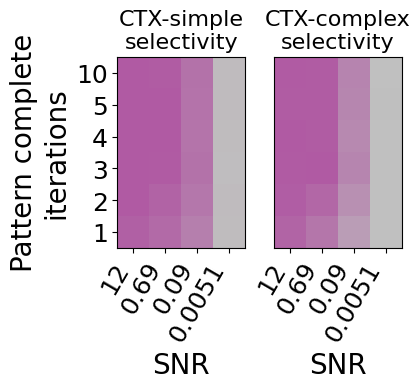

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(4, 4), constrained_layout=True, sharey=True)

plot_matrices = [
    (pattern_complete_iteration_ctx_simple_selectivity.T, "CTX-simple\nselectivity"),
    (pattern_complete_iteration_ctx_complex_selectivity.T, "CTX-complex\nselectivity"),
]
vmin = min(matrix.min() for matrix, _ in plot_matrices)
vmax = max(matrix.max() for matrix, _ in plot_matrices)

for ax, (matrix, title) in zip(axes, plot_matrices):
    im = ax.imshow(
        matrix,
        origin="lower",
        cmap=gray_purple,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("SNR", fontsize=20)
    ax.set_ylabel("Pattern complete\niterations", fontsize=20)
    ax.set_xticks(np.arange(len(snr_values)))
    ax.set_xticklabels([f"{value:.2g}" for value in snr_values], rotation=60, ha="right")
    ax.set_yticks(np.arange(len(pattern_complete_iteration_values)))
    ax.set_yticklabels(pattern_complete_iteration_values)
    ax.tick_params(axis="both", labelsize=18)
axes[1].yaxis.set_visible(False)


plt.savefig("Figures/SVG/S9c.svg", dpi=300, transparent=True)

In [11]:
def build_sparsity_adapted_parameters(default_input_params, default_network_params, target_sparsity):
    from copy import deepcopy

    import numpy as np
    import torch

    from src.utils.episode_generation_protocol import LatentSpace

    if not (0 < float(target_sparsity) <= 1):
        raise ValueError("target_sparsity must satisfy 0 < target_sparsity <= 1.")

    adapted_input_params = deepcopy(default_input_params)
    adapted_network_params = deepcopy(default_network_params)

    max_semantic_load_input = int(adapted_network_params["max_semantic_load_input"])
    num_latents = 2

    concepts_per_latent = int(round(1.0 / float(target_sparsity)))
    if not np.isclose(float(target_sparsity), 1.0 / concepts_per_latent):
        raise ValueError(
            "target_sparsity must be the reciprocal of an integer so it can represent 1 active concept out of N."
        )
    if concepts_per_latent < 2:
        raise ValueError("Need at least two concepts per latent factor.")

    sensory_assembly_size = int(
        round(
            float(adapted_network_params["mtl_sensory_size_subregions"][0])
            * float(adapted_network_params["mtl_sensory_sparsity"][0])
            / num_latents
        )
    )
    semantic_assembly_size = int(
        round(
            float(adapted_network_params["mtl_semantic_size_subregions"][0])
            * float(adapted_network_params["mtl_semantic_sparsity"][0])
            / num_latents
        )
    )
    ctx_simple_assembly_size = int(
        round(
            float(adapted_network_params["ctx_size_subregions"][0])
            * float(adapted_network_params["ctx_sparsity"][0])
            / num_latents
        )
    )
    ctx_complex_assembly_size = int(
        round(
            float(adapted_network_params["ctx_size_subregions"][1])
            * float(adapted_network_params["ctx_sparsity"][1])
        )
    )

    assembly_sizes = {
        "sensory": sensory_assembly_size,
        "semantic": semantic_assembly_size,
        "ctx_simple": ctx_simple_assembly_size,
        "ctx_complex": ctx_complex_assembly_size,
    }
    if len(set(assembly_sizes.values())) != 1:
        raise ValueError(f"Assembly sizes do not match across regions: {assembly_sizes}")
    assembly_size = sensory_assembly_size

    default_concepts_per_latent = int(
        round(
            float(default_network_params["mtl_semantic_size_subregions"][0])
            / float(semantic_assembly_size)
            / num_latents
        )
    )
    default_num_episodes = default_concepts_per_latent ** num_latents
    default_ctx_complex_capacity_factor = float(default_network_params["ctx_size_subregions"][1]) / float(
        default_num_episodes * ctx_complex_assembly_size
    )

    simple_concepts_total = num_latents * concepts_per_latent
    num_episodes = concepts_per_latent ** num_latents

    latent_space_specs = {
        "num": num_latents,
        "total_sizes": [assembly_size * concepts_per_latent] * num_latents,
        "act_sizes": [assembly_size] * num_latents,
        "dims": [concepts_per_latent] * num_latents,
        "prob_list": [
            0.5 / concepts_per_latent
            if i == j
            else 0.5 / (concepts_per_latent * (concepts_per_latent - 1))
            for i in range(concepts_per_latent)
            for j in range(concepts_per_latent)
        ],
    }

    sen_size = sum(latent_space_specs["total_sizes"])
    mtl_sensory_size = sen_size
    mtl_semantic_size = simple_concepts_total * assembly_size
    ctx_simple_size = simple_concepts_total * assembly_size
    ctx_complex_size = int(
        np.ceil(default_ctx_complex_capacity_factor * num_episodes * assembly_size)
    )

    simple_wake_sparsity = float(target_sparsity)
    simple_sleep_sparsity = float(target_sparsity) / num_latents
    complex_sparsity = float(assembly_size) / float(ctx_complex_size)

    adapted_network_params["sen_size_subregions"] = torch.tensor([sen_size])
    adapted_network_params["sen_sparsity"] = torch.tensor([simple_wake_sparsity])
    adapted_network_params["sen_sparsity_sleep"] = torch.tensor([simple_wake_sparsity])

    adapted_network_params["mtl_sensory_size_subregions"] = torch.tensor([mtl_sensory_size])
    adapted_network_params["mtl_sensory_sparsity"] = torch.tensor([simple_wake_sparsity])
    adapted_network_params["mtl_sensory_sparsity_sleep"] = torch.tensor([simple_sleep_sparsity])

    adapted_network_params["mtl_semantic_size_subregions"] = torch.tensor([mtl_semantic_size])
    adapted_network_params["mtl_semantic_sparsity"] = torch.tensor([simple_wake_sparsity])
    adapted_network_params["mtl_semantic_sparsity_sleep"] = torch.tensor([simple_sleep_sparsity])

    adapted_network_params["mtl_size_subregions"] = torch.tensor([mtl_sensory_size, mtl_semantic_size])
    adapted_network_params["mtl_sparsity"] = torch.tensor([simple_wake_sparsity, simple_wake_sparsity])
    adapted_network_params["mtl_sparsity_sleep"] = torch.tensor([simple_sleep_sparsity, simple_sleep_sparsity])

    adapted_network_params["ctx_size_subregions"] = torch.tensor([ctx_simple_size, ctx_complex_size])
    adapted_network_params["ctx_sparsity"] = torch.tensor([simple_wake_sparsity, complex_sparsity])
    adapted_network_params["ctx_sparsity_sleep"] = torch.tensor([simple_sleep_sparsity, complex_sparsity])

    adapted_input_params["latent_space"] = LatentSpace(**latent_space_specs)
    adapted_input_params["latent_space_specs"] = latent_space_specs

    return adapted_input_params, adapted_network_params


In [12]:
default_input_params = {
    "num_days": 600,
    "day_length": 80,
    "mean_duration": 5,
    "fixed_duration": True,
    "num_swaps": 4,
}

default_network_params = network_parameters

adapted_input_params, adapted_network_params = build_sparsity_adapted_parameters(
    default_input_params=default_input_params,
    default_network_params=default_network_params,
    target_sparsity=0.1,
)

print("adapted_input_params")
print(adapted_input_params)

print("\nadapted_network_params")
print(adapted_network_params)

adapted_input_params
{'num_days': 600, 'day_length': 80, 'mean_duration': 5, 'fixed_duration': True, 'num_swaps': 4, 'latent_space': <src.utils.episode_generation_protocol.LatentSpace object at 0x15ad567f0>, 'latent_space_specs': {'num': 2, 'total_sizes': [100, 100], 'act_sizes': [10, 10], 'dims': [10, 10], 'prob_list': [0.05, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.05, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.05, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556, 0.005555555555555556,

In [13]:
sparsity_values = [0.1, 0.125, 0.2, 0.25, 0.5]

sparsity_network_override_keys = [
    "sen_size_subregions",
    "sen_sparsity",
    "sen_sparsity_sleep",
    "mtl_sensory_size_subregions",
    "mtl_sensory_sparsity",
    "mtl_sensory_sparsity_sleep",
    "mtl_semantic_size_subregions",
    "mtl_semantic_sparsity",
    "mtl_semantic_sparsity_sleep",
    "mtl_size_subregions",
    "mtl_sparsity",
    "mtl_sparsity_sleep",
    "ctx_size_subregions",
    "ctx_sparsity",
    "ctx_sparsity_sleep",
]


def run_sparsity_noise_sweep_point(seed, num_swaps, sparsity):
    adapted_input_params, adapted_network_params = build_sparsity_adapted_parameters(
        default_input_params=default_input_params,
        default_network_params=default_network_params,
        target_sparsity=sparsity,
    )
    network_parameter_overrides = {
        key: adapted_network_params[key] for key in sparsity_network_override_keys
    }
    input_parameter_overrides = {
        "day_length": adapted_input_params["day_length"],
        "mean_duration": adapted_input_params["mean_duration"],
        "fixed_duration": adapted_input_params["fixed_duration"],
        "num_swaps": num_swaps,
        "latent_space_specs": adapted_input_params["latent_space_specs"],
    }
    summary = run_default_600_day_selectivity(
        seed=seed,
        print_rate=np.inf,
        network_parameter_overrides=network_parameter_overrides,
        input_parameter_overrides=input_parameter_overrides,
    )
    return {
        "seed": int(seed),
        "sparsity": float(sparsity),
        "num_swaps": int(num_swaps),
        "ctx_simple_mean_selectivity": summary["ctx_simple_mean_selectivity"],
        "ctx_complex_mean_selectivity": summary["ctx_complex_mean_selectivity"],
        "mtl_semantic_simple_mean_selectivity": summary["mtl_semantic_simple_mean_selectivity"],
    }


In [14]:
sparsity_noise_jobs = [
    (seed, num_swaps, sparsity)
    for sparsity in sparsity_values
    for num_swaps in num_swaps_values
    for seed in seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=min(num_cpu, len(sparsity_noise_jobs))) as pool:
    sparsity_noise_results = pool.starmap(
        run_sparsity_noise_sweep_point,
        sparsity_noise_jobs,
    )

sparsity_noise_selectivity_seed_matrix = np.full(
    (len(sparsity_values), len(num_swaps_values), num_seeds, len(measure_names)),
    np.nan,
)

for result in sparsity_noise_results:
    i = sparsity_values.index(result["sparsity"])
    j = num_swaps_values.index(result["num_swaps"])
    k = seeds.index(result["seed"])
    sparsity_noise_selectivity_seed_matrix[i, j, k, 0] = result["ctx_simple_mean_selectivity"]
    sparsity_noise_selectivity_seed_matrix[i, j, k, 1] = result["ctx_complex_mean_selectivity"]
    sparsity_noise_selectivity_seed_matrix[i, j, k, 2] = result["mtl_semantic_simple_mean_selectivity"]

sparsity_noise_selectivity_matrix = np.nanmean(sparsity_noise_selectivity_seed_matrix, axis=2)
sparsity_noise_selectivity_matrix_std = np.nanstd(sparsity_noise_selectivity_seed_matrix, axis=2)

print("sparsity_noise_selectivity_matrix shape (mean over seeds):", sparsity_noise_selectivity_matrix.shape)
print("sparsity_noise_selectivity_matrix_std shape:", sparsity_noise_selectivity_matrix_std.shape)


sparsity_noise_selectivity_matrix shape (mean over seeds): (5, 4, 3)
sparsity_noise_selectivity_matrix_std shape: (5, 4, 3)


NameError: name 'snr_values' is not defined

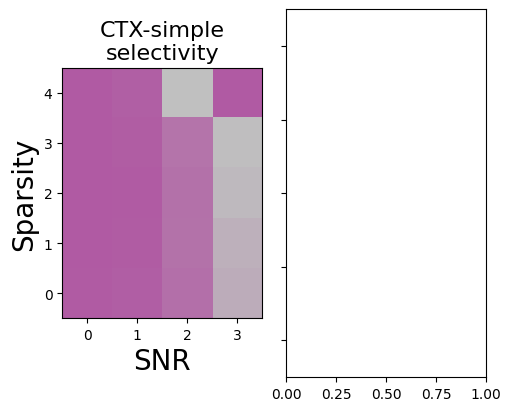

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(5, 4), constrained_layout=True, sharey=True)

plot_matrices = [
    (sparsity_noise_selectivity_matrix[..., 0], "CTX-simple\nselectivity"),
    (sparsity_noise_selectivity_matrix[..., 1], "CTX-complex\nselectivity"),
]
vmin = min(matrix.min() for matrix, _ in plot_matrices)
vmax = max(matrix.max() for matrix, _ in plot_matrices)

for ax, (matrix, title) in zip(axes, plot_matrices):
    im = ax.imshow(
        matrix,
        origin="lower",
        cmap=gray_purple,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("SNR", fontsize=20)
    ax.set_ylabel("Sparsity", fontsize=20)
    ax.set_xticks(np.arange(len(snr_values)))
    ax.set_xticklabels([f"{value:.2g}" for value in snr_values], rotation=60, ha="right")
    ax.set_yticks(np.arange(len(sparsity_values)))
    ax.set_yticklabels(sparsity_values)
    ax.tick_params(axis="both", labelsize=18)
axes[1].yaxis.set_visible(False)

plt.savefig("Figures/SVG/S9d.svg", dpi=300, transparent=True)

In [30]:
outgoing_feedforward_network_overrides = {
    "max_pre_ctx_mtl": 1.0,
    "max_post_ctx_mtl": np.inf,
    "max_pre_mtl_semantic_ctx": 1.0,
    "max_post_mtl_semantic_ctx": np.inf,
}


def run_feedforward_norm_comparison_point(seed, num_swaps, use_outgoing_feedforward_norm):
    network_class = SSCNetworkOutgoingFF if use_outgoing_feedforward_norm else SSCNetwork
    network_parameter_overrides = (
        outgoing_feedforward_network_overrides
        if use_outgoing_feedforward_norm
        else None
    )
    summary = run_default_600_day_selectivity(
        seed=seed,
        print_rate=np.inf,
        network_parameter_overrides=network_parameter_overrides,
        input_parameter_overrides={"num_swaps": num_swaps},
        network_class=network_class,
    )
    return {
        "seed": int(seed),
        "num_swaps": int(num_swaps),
        "use_outgoing_feedforward_norm": bool(use_outgoing_feedforward_norm),
        "ctx_simple_mean_selectivity": summary["ctx_simple_mean_selectivity"],
        "ctx_complex_mean_selectivity": summary["ctx_complex_mean_selectivity"],
        "mtl_semantic_simple_mean_selectivity": summary["mtl_semantic_simple_mean_selectivity"],
    }


In [31]:
comparison_jobs = [
    (seed, num_swaps, use_outgoing_feedforward_norm)
    for num_swaps in num_swaps_values
    for use_outgoing_feedforward_norm in [False, True]
    for seed in seeds
]

ctx = multiprocessing.get_context("fork")
with ctx.Pool(processes=min(num_cpu, len(comparison_jobs))) as pool:
    feedforward_norm_comparison_results = pool.starmap(
        run_feedforward_norm_comparison_point,
        comparison_jobs,
    )

print("comparison points:", len(feedforward_norm_comparison_results))


comparison points: 32


In [32]:
comparison_curves = {
    "default": {
        "ctx_simple": np.full((len(num_swaps_values), num_seeds), np.nan),
        "ctx_complex": np.full((len(num_swaps_values), num_seeds), np.nan),
    },
    "outgoing": {
        "ctx_simple": np.full((len(num_swaps_values), num_seeds), np.nan),
        "ctx_complex": np.full((len(num_swaps_values), num_seeds), np.nan),
    },
}

for result in feedforward_norm_comparison_results:
    i = num_swaps_values.index(result["num_swaps"])
    key = "outgoing" if result["use_outgoing_feedforward_norm"] else "default"
    k = seeds.index(result["seed"])
    comparison_curves[key]["ctx_simple"][i, k] = result["ctx_simple_mean_selectivity"]
    comparison_curves[key]["ctx_complex"][i, k] = result["ctx_complex_mean_selectivity"]

In [ ]:
recording_parameters = {
    "regions": ["mtl_sensory", "mtl", "ctx"],
    "rate_activity": np.inf,
    "connections": ["ctx_mtl"],
    "rate_connectivity": np.inf,
}

input_params = deepcopy(default_input_params)
input_params["num_days"] = 1

latent_specs = deepcopy(default_latent_specs)

grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seeds = range(1800)
sleep_duration_A_curves = [1, 10, 30, 100]
curve_num_cpu = 12

import multiprocessing


def run_sleep_duration_A_curve(sleep_duration_A):
    net_params = deepcopy(network_parameters)
    net_params["sleep_duration_A"] = int(sleep_duration_A)
    net_params["sleep_duration_B"] = 0

    results = analyze_focal_concept_sleep_receptive_fields_many_seeds(
        net_params,
        recording_parameters,
        input_params,
        latent_specs,
        seeds=seeds,
        focal_probability_grid=grid,
        num_cpu=curve_num_cpu,
        start_method="fork",
    )

    discrete = get_discrete_concept_formation_probability(
        results["all_focal_concept_pairs"]
    )

    return {
        "sleep_duration_A": int(sleep_duration_A),
        "results": results,
        "discrete": discrete,
    }


with multiprocessing.get_context("fork").Pool(processes=curve_num_cpu) as pool:
    sleep_duration_curve_results = pool.map(
        run_sleep_duration_A_curve,
        sleep_duration_A_curves,
    )

sleep_duration_curve_results = {
    entry["sleep_duration_A"]: entry
    for entry in sleep_duration_curve_results
}

results = sleep_duration_curve_results[sleep_duration_A_curves[-1]]["results"]
discrete = sleep_duration_curve_results[sleep_duration_A_curves[-1]]["discrete"]



AssertionError: daemonic processes are not allowed to have children

In [ ]:
recording_parameters = {
    "regions": ["mtl_sensory", "mtl", "ctx"],
    "rate_activity": np.inf,
    "connections": ["ctx_mtl"],
    "rate_connectivity": np.inf,
}

input_params = deepcopy(default_input_params)
input_params["num_days"] = 1

latent_specs = deepcopy(default_latent_specs)

grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seeds = range(1800)
sleep_duration_A_curves = [1, 10, 30, 100]
curve_num_cpu = 12

import multiprocessing


def run_sleep_duration_A_curve(sleep_duration_A):
    net_params = deepcopy(network_parameters)
    net_params["sleep_duration_A"] = int(sleep_duration_A)
    net_params["sleep_duration_B"] = 0

    results = analyze_focal_concept_sleep_receptive_fields_many_seeds(
        net_params,
        recording_parameters,
        input_params,
        latent_specs,
        seeds=seeds,
        focal_probability_grid=grid,
        num_cpu=curve_num_cpu,
        start_method="fork",
    )

    discrete = get_discrete_concept_formation_probability(
        results["all_focal_concept_pairs"]
    )

    return {
        "sleep_duration_A": int(sleep_duration_A),
        "results": results,
        "discrete": discrete,
    }


with multiprocessing.get_context("fork").Pool(processes=curve_num_cpu) as pool:
    sleep_duration_curve_results = pool.map(
        run_sleep_duration_A_curve,
        sleep_duration_A_curves,
    )

sleep_duration_curve_results = {
    entry["sleep_duration_A"]: entry
    for entry in sleep_duration_curve_results
}

results = sleep_duration_curve_results[sleep_duration_A_curves[-1]]["results"]
discrete = sleep_duration_curve_results[sleep_duration_A_curves[-1]]["discrete"]



AssertionError: daemonic processes are not allowed to have children

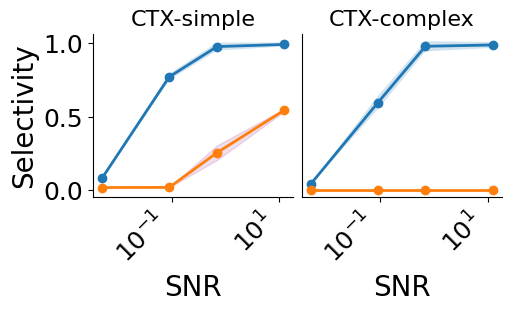

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(5, 3), constrained_layout=True, sharey=True)

plot_specs = [
    ("ctx_simple", "CTX-simple"),
    ("ctx_complex", "CTX-complex"),
]

for ax, (metric_key, title) in zip(axes, plot_specs):
    ax.plot(
        snr_values,
        np.nanmean(comparison_curves["default"][metric_key], axis=1),
        marker="o",
        linewidth=2,
        label="Default"
    )
    default_mean = np.nanmean(comparison_curves["default"][metric_key], axis=1)
    default_std = np.nanstd(comparison_curves["default"][metric_key], axis=1)
    ax.fill_between(snr_values, default_mean - default_std, default_mean + default_std, alpha=0.2)
    ax.plot(
        snr_values,
        np.nanmean(comparison_curves["outgoing"][metric_key], axis=1),
        marker="o",
        linewidth=2,
        label="Outgoing Normalization\nin Feed-Forward Connections",
    )
    outgoing_mean = np.nanmean(comparison_curves["outgoing"][metric_key], axis=1)
    outgoing_std = np.nanstd(comparison_curves["outgoing"][metric_key], axis=1)
    ax.fill_between(snr_values, outgoing_mean - outgoing_std, outgoing_mean + outgoing_std, color=purple, alpha=0.2)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("SNR", fontsize=20)
    ax.set_ylabel("Selectivity", fontsize=20)
    ax.set_xticks(snr_values)
    ax.set_xticklabels([f"{value:.2g}" for value in snr_values], rotation=45, ha="right")
    ax.tick_params(axis="both", labelsize=18)
    ax.set_xscale("log")

axes[1].yaxis.set_visible(False)
sns.despine()


plt.savefig("Figures/SVG/S9e.svg", dpi=300, transparent=True)